In [1]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit import DataStructs
from rdkit.Chem.SaltRemover import SaltRemover
import pandas as pd 
import numpy as np

# generate fingerprints from smiles
smiles_col = 'OriginalSmiles'
target = 'pKa'

data_df = pd.read_csv("./dw_data/Opt1_acidic_tr.csv")
smiles_mols = data_df[smiles_col] 

In [2]:
# below code generates rdkit mols, then removes salts, then generates fingerprints
saltRemover = SaltRemover(defnFilename='./Salts.txt')
FP_radius, FP_size = 2, 1024

rdkit_mols = smiles_mols.astype(str).apply((lambda x: Chem.MolFromSmiles(x)))
rdkit_mols = rdkit_mols.apply((lambda x: saltRemover.StripMol(x)))

X = rdkit_mols.apply((lambda x: AllChem.GetMorganFingerprintAsBitVect(x, 
                                                                      radius=FP_radius, 
                                                                      nBits=FP_size).ToBitString()))

X = np.vstack([np.fromstring(x, 'u1') - ord('0') for x in X]).astype(float) # this is from: https://stackoverflow.com/a/29091970
y = data_df[target].values

C:\Users\Fahad\AppData\Local\Temp\ipykernel_51264\539821293.py:12: DeprecationWarning: The binary mode of fromstring is deprecated, as it behaves surprisingly on unicode inputs. Use frombuffer instead
  X = np.vstack([np.fromstring(x, 'u1') - ord('0') for x in X]).astype(float) # this is from: https://stackoverflow.com/a/29091970


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=11)

print(f'Shape (X, y): ({X.shape}, {y.shape})')
print(f'Shape (X_train, y_train): ({X_train.shape}, {y_train.shape})')
print(f'Shape (X_test, y_test): ({X_test.shape}, {y_test.shape})')

Shape (X, y): ((2220, 1024), (2220,))
Shape (X_train, y_train): ((1665, 1024), (1665,))
Shape (X_test, y_test): ((555, 1024), (555,))


In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

rf_reg = RandomForestRegressor(n_estimators=200, 
                               min_samples_leaf=1, 
                               max_features="log2")

rf_reg.fit(X_train, y_train)

print(r2_score(y_train, rf_reg.predict(X_train)))
print(r2_score(y_test, rf_reg.predict(X_test)))

0.9422534470815277
0.5833617621011614


In [5]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
import xgboost as xgb

# Define the base model
xgbr = xgb.XGBRegressor(random_state=42, objective='reg:squarederror')

# Simplified hyperparameter grid
param_grid = {
    'n_estimators': [300],
    'max_depth': [3, 6],
    'learning_rate': [0.1, 0.2],
    'subsample': [0.8],
    'colsample_bytree': [0.8, 1.0],
    'reg_lambda': [1, 5]
}


# Perform GridSearchCV for hyperparameter tuning
grid_search = GridSearchCV(
    estimator=xgbr,
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=5,
    verbose=2
)

# Fit the grid search on the training data
grid_search.fit(X_train, y_train)

# Extract the best model
best_xgbr_model = grid_search.best_estimator_

# Evaluate the best model on the test data
y_pred_test = best_xgbr_model.predict(X_test)
y_pred_train = best_xgbr_model.predict(X_train)

# Calculate metrics
best_model_metrics = {
    'Train R^2': r2_score(y_train, y_pred_train),
    'Test R^2': r2_score(y_test, y_pred_test),
    'Test MAE': mean_absolute_error(y_test, y_pred_test),
    'Test MSE': mean_squared_error(y_test, y_pred_test),
    'Test RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test))
}

# Output the best parameters and performance metrics
print("Best Parameters:", grid_search.best_params_)
print("Best Model Performance:", best_model_metrics)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


KeyboardInterrupt: 

In [ ]:
sns.histplot(y)

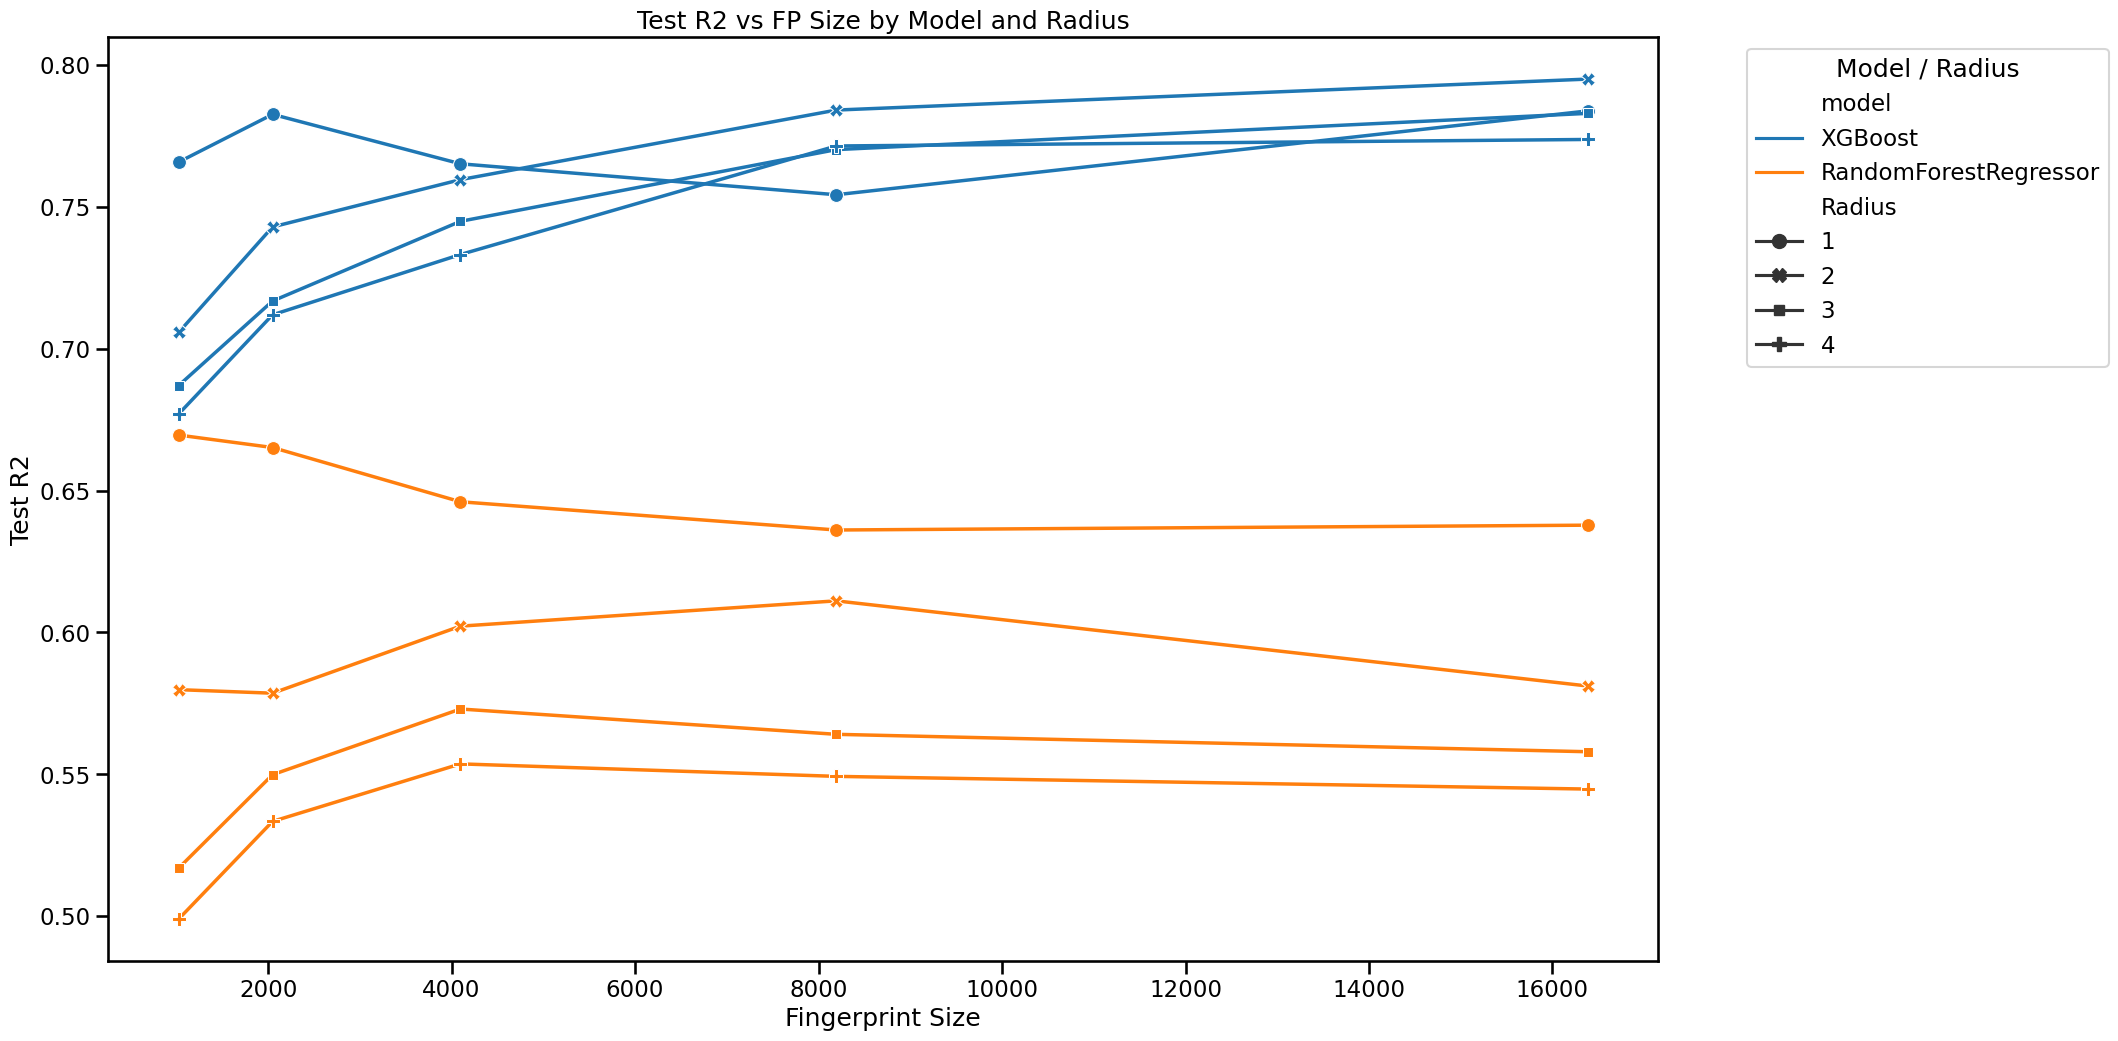

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the CSV data into a DataFrame
df = pd.read_csv('./performance_all_radii.csv')

# Set a context to enlarge fonts and other elements
sns.set_context("talk")

# Create a larger figure
plt.figure(figsize=(20, 12))

# Create the line plot with thicker lines
ax = sns.lineplot(
    data=df,
    x="fingerprint_size",
    y="Test R2",
    hue="model",
    style="Radius",
    markers=True,
    dashes=False,
    linewidth=2.5  # Thicker lines for better visibility
)

# Increase marker sizes for all lines
for line in ax.lines:
    line.set_markersize(10)

# Add labels and a title to the plot
plt.title("Test R2 vs FP Size by Model and Radius")
plt.xlabel("Fingerprint Size")
plt.ylabel("Test R2")

# Adjust the legend position
plt.legend(title="Model / Radius", bbox_to_anchor=(1.05, 1), loc='upper left')

# Save the high-resolution figure
plt.savefig("test_r2_by_model_and_radius.png", dpi=300, bbox_inches='tight')

# Display the plot
plt.show()
